
# Домашнє завдання

Налаштувалися на виконання нового завдання? Тодi починаємо!

Сьогодні ви використаєте знання, отримані про дискримінантні методи для власної реалізації метода QDA.

Це допоможе закрiпити наступні навички:  

- матричні операції, до яких зводяться програмні реалізації розглянутих методів;
- особливості роботи метода QDA.

## Завдання (крок за кроком)

Для цієї задачі необхідно буде завантажити набір даних Iris з бібліотеки Sklear.

 Для виконання завдання необхідно виконати такі кроки:

1. Завантажити набір даних за допомогою load_iris() бібліотеки sklearn.  

2. Розподілити дані на навчальні та для тестування за допомогою train_test_split() бібліотеки sklearn.

3. Викорати вибірку ознак окремо для кожного класа.

4. Реалізувати розрахунок матриць коваріації для набору ознак кожного класа.

5. Реалізувати розрахунок обернених матриць коваріації.

6. Обчислити апріорні імовірності кожного класа у тренувальних даних.

7. Реалізувати функцію обчислення значень дискримінантної функції для одного рядка (вектора) тестових даних.

8. Реалізувати функцію обчислення значень дискримінантної функції та імовірностей приналежності кожному класу для всієї матриці тестових даних.

9. Виконати прогнозування на тестових даних за допомогою функії QuadraticDiscriminantAnalysis() бібліотеки sklearn та порівняти отримані результати.
10. Зробити висновок про ступінь схожості результатів, отриманих власною функцією та бібліотекою sklearn.


## Пiдказки

Для виконання завдання використовуйте функції numpy, та алгоритми з конспекту до цієї теми.

## Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

## Критерії прийому

- Усі вказані етапи виконані.
- До Colab додані висновки.

## Формат оцінювання
- Оцiнка вiд 0 до 100

## Приклад

- функція розрахунку значень дискримінантної функії для вектора даних (g())
- функція розрахунку значень дискримінантної функції та частот розподілу за класами на всіх тестових даних (g_matrix())

In [ ]:
def g(x_test, X_class, X_cov, X_inv_cov, X_prob):
    cov_det = np.linalg.det(X_cov)
    log_cov_det = np.log(cov_det)
    x_mean = np.reshape(np.mean(X_class, axis=0), (np.shape(X_class)[1], 1))
    diff = x_test.reshape(-1, 1) - x_mean
    g_i = -0.5 * diff.T @ X_inv_cov @ diff - 0.5 * log_cov_det + np.log(X_prob)
    return g_i

def g_matrix(X_test, X_class, X_cov, X_inv_cov, X_prob):
    g_val = []
    g_proba = []
    for i in range(len(X_test)):
        x_test = X_test[i]
        g_0 = g(x_test, X_class[0], X_cov[0], X_inv_cov[0], X_prob[0])
        g_1 = g(x_test, X_class[1], X_cov[1], X_inv_cov[1], X_prob[1])
        g_2 = g(x_test, X_class[2], X_cov[2], X_inv_cov[2], X_prob[2])
        g_i = np.array([g_0[0][0], g_1[0][0], g_2[0][0]])
        likelihood = np.exp(g_i - np.max(g_i))
        res = likelihood / np.sum(likelihood)
        g_val.append(g_i)
        g_proba.append(res)
    return np.array(g_val), np.array(g_proba)


Генерація синтетичних даних

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from numpy.linalg import inv
import matplotlib.pyplot as plt
import seaborn as sns

features, labels = make_classification(
    n_samples=150, n_features=4, n_informative=4, n_redundant=0,
    n_clusters_per_class=1, n_classes=3, random_state=42
)

features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

features_train_df = pd.DataFrame(features_train, columns=[f'feature_{i}' for i in range(features_train.shape[1])])
labels_train_df = pd.DataFrame(labels_train, columns=['label'])
train_df = pd.concat([features_train_df, labels_train_df], axis=1)

filtered_class_0 = train_df[train_df['label'] == 0]
filtered_class_1 = train_df[train_df['label'] == 1]
filtered_class_2 = train_df[train_df['label'] == 2]

x_0 = np.array(filtered_class_0.iloc[:, :-1])
x_1 = np.array(filtered_class_1.iloc[:, :-1])
x_2 = np.array(filtered_class_2.iloc[:, :-1])

x_0_cov = np.cov(x_0.T)
x_1_cov = np.cov(x_1.T)
x_2_cov = np.cov(x_2.T)

inv_cov_0 = inv(x_0_cov)
inv_cov_1 = inv(x_1_cov)
inv_cov_2 = inv(x_2_cov)

P_0 = len(filtered_class_0) / len(train_df)
P_1 = len(filtered_class_1) / len(train_df)
P_2 = len(filtered_class_2) / len(train_df)


g_val, g_proba = g_matrix(
    features_test,
    [x_0, x_1, x_2],
    [x_0_cov, x_1_cov, x_2_cov],
    [inv_cov_0, inv_cov_1, inv_cov_2],
    [P_0, P_1, P_2]
)

qda = QuadraticDiscriminantAnalysis()
qda.fit(features_train, labels_train)
values_qda = qda._decision_function(features_test)
proba_qda = qda.predict_proba(features_test)

dataframe=pd.DataFrame({
    "g0_own": g_val[:,0], "g1_own": g_val[:,1], "g2_own": g_val[:,2],
    "g0_sklearn": values_qda[:,0], "g1_sklearn": values_qda[:,1], "g2_sklearn": values_qda[:,2],
    "P0_own": g_proba[:,0], "P1_own": g_proba[:,1], "P2_own": g_proba[:,2],
    "P0_sklearn": proba_qda[:,0], "P1_sklearn": proba_qda[:,1], "P2_sklearn": proba_qda[:,2],
})


In [ ]:
dataframe

,g0_own,g1_own,g2_own,g0_sklearn,g1_sklearn,g2_sklearn,P0_own,P1_own,P2_own,P0_sklearn,P1_sklearn,P2_sklearn
0,-24.374000,-2.064104,-63.270303,-24.374000,-2.064104,-63.270303,2.046139e-10,1.000000e+00,2.621111e-27,2.046139e-10,1.000000e+00,2.621111e-27
1,-1819.455273,-4.958383,-37.538504,-1819.455273,-4.958383,-37.538504,0.000000e+00,1.000000e+00,7.089790e-15,0.000000e+00,1.000000e+00,7.089790e-15
2,-5493.604315,-42.367341,-4.970315,-5493.604315,-42.367341,-4.970315,0.000000e+00,5.736909e-17,1.000000e+00,0.000000e+00,5.736909e-17,1.000000e+00
3,0.056664,-13.351912,-47.350684,0.056664,-13.351912,-47.350684,9.999985e-01,1.502203e-06,2.577802e-21,9.999985e-01,1.502203e-06,2.577802e-21
4,-924.092029,-1.672806,-60.550481,-924.092029,-1.672806,-60.550481,0.000000e+00,1.000000e+00,2.689989e-26,0.000000e+00,1.000000e+00,2.689989e-26
5,-611.683109,-0.643465,-40.966551,-611.683109,-0.643465,-40.966551,4.254558e-266,1.000000e+00,3.075431e-18,4.254558e-266,1.000000e+00,3.075431e-18
6,-789.014145,-2.461650,-74.361158,-789.014145,-2.461650,-74.361158,0.000000e+00,1.000000e+00,5.948952e-32,0.000000e+00,1.000000e+00,5.948952e-32
7,-431.021523,-3.946647,-56.244468,-431.021523,-3.946647,-56.244468,3.339934e-186,1.000000e+00,1.937961e-23,3.339934e-186,1.000000e+00,1.937961e-23
8,-0.041963,-3.569618,-255.003316,-0.041963,-3.569618,-255.003316,9.714645e-01,2.853555e-02,1.816011e-111,9.714645e-01,2.853555e-02,1.816011e-111
9,0.768285,-7.258043,-416.057529,0.768285,-7.258043,-416.057529,9.996734e-01,3.266392e-04,9.434245e-182,9.996734e-01,3.266392e-04,9.434245e-182


Візуалізація кордонів класифікації для 2х ознак

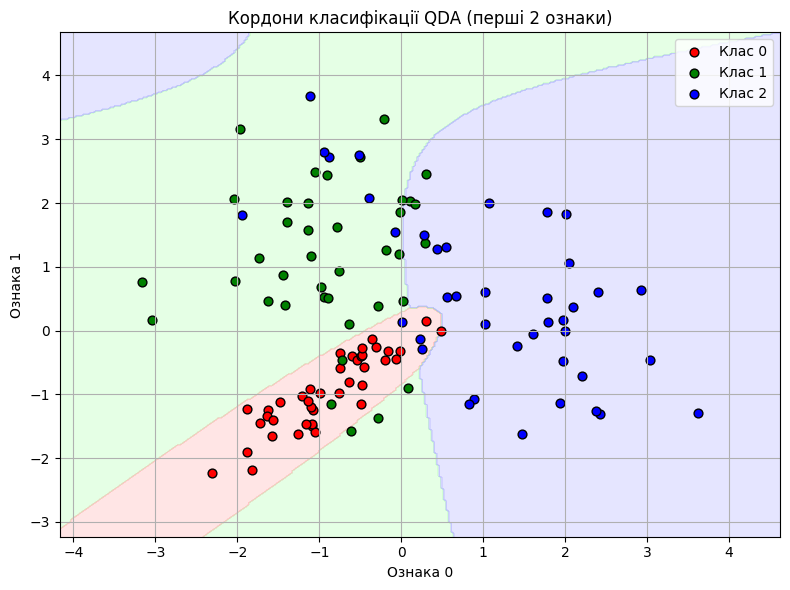

In [ ]:
from matplotlib.colors import ListedColormap


X_vis = features_train[:, :2]
y_vis = labels_train


qda_vis = QuadraticDiscriminantAnalysis()
qda_vis.fit(X_vis, y_vis)


x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = qda_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(8, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ['red', 'green', 'blue']

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
for idx, color in enumerate(cmap_bold):
    plt.scatter(X_vis[y_vis == idx, 0], X_vis[y_vis == idx, 1],
                label=f'Клас {idx}', edgecolor='k', s=40, color=color)

plt.title("Кордони класифікації QDA (перші 2 ознаки)")
plt.xlabel("Ознака 0")
plt.ylabel("Ознака 1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---
# ✅ Виконання завдання: QDA на наборі даних Iris

У цьому розділі реалізуємо **квадратичний дискримінантний аналіз (QDA)** на наборі даних **Iris**, лише за допомогою `numpy`, а потім порівняємо результат із готовою реалізацією `QuadraticDiscriminantAnalysis()` з бібліотеки `sklearn`.

**Теоретична основа.** У QDA вважається, що ознаки кожного класу $\omega_i$ мають нормальний розподіл зі своїм вектором середніх $\mu_i$ та **своєю** матрицею коваріації $\Sigma_i$. Дискримінантна функція класу $\omega_i$ для вектора $x$:

$$g_i(x) = -\frac{1}{2}(x-\mu_i)^{T}\,\Sigma_i^{-1}\,(x-\mu_i)\;-\;\frac{1}{2}\ln|\Sigma_i|\;+\;\ln P(\omega_i)$$

Об'єкт відносять до класу з **найбільшим** значенням $g_i(x)$. Апостеріорні імовірності отримуємо через softmax:

$$P(\omega_i \mid x)=\frac{e^{g_i(x)}}{\sum_j e^{g_j(x)}}$$

(спільний доданок $-\frac{d}{2}\ln 2\pi$ однаковий для всіх класів і при нормуванні скорочується).

**План роботи:**

| Крок | Що робимо |
|---|---|
| 1 | Завантажуємо Iris через `load_iris()` |
| 2 | Ділимо на навчальну та тестову вибірки (`train_test_split`) |
| 3 | Виділяємо вибірку ознак окремо для кожного класу |
| 4 | Рахуємо матриці коваріації кожного класу |
| 5 | Рахуємо обернені матриці коваріації |
| 6 | Обчислюємо апріорні імовірності класів |
| 7 | Функція дискримінантної функції для одного вектора |
| 8 | Функція для всієї тестової матриці (значення $g_i$ та імовірності) |
| 9 | Прогноз через `QuadraticDiscriminantAnalysis()` і порівняння |
| 10 | Висновок про схожість результатів |

In [1]:
# Підключаємо потрібні бібліотеки (розділ самодостатній: можна запускати окремо від прикладу вище)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

# Акуратний вивід чисел
np.set_printoptions(precision=4, suppress=True, linewidth=120)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)

RANDOM_STATE = 42   # для відтворюваності результатів

## Крок 1. Завантаження набору даних Iris

Набір Iris містить 150 квітів ірисів трьох видів (по 50 кожного): *setosa*, *versicolor*, *virginica*. Для кожної квітки виміряно 4 ознаки: довжину та ширину чашолистка (sepal) і пелюстки (petal) у сантиметрах.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

feature_names = iris.feature_names
class_names = iris.target_names
n_classes = len(class_names)

print(f"Розмірність матриці ознак X: {X.shape}  (об'єктів × ознак)")
print(f"Розмірність вектора міток y: {y.shape}")
print(f"Ознаки: {feature_names}")
print(f"Класи:  {dict(enumerate(map(str, class_names)))}")
print(f"Кількість об'єктів у кожному класі: {np.bincount(y)}")

iris_df = pd.DataFrame(X, columns=feature_names)
iris_df["class"] = pd.Categorical.from_codes(y, class_names)
iris_df.head()

Розмірність матриці ознак X: (150, 4)  (об'єктів × ознак)
Розмірність вектора міток y: (150,)
Ознаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Класи:  {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
Кількість об'єктів у кожному класі: [50 50 50]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Крок 2. Розподіл даних на навчальну та тестову вибірки

Залишаємо 20 % даних для тестування (`test_size=0.2`), зафіксувавши `random_state=42`, щоб результати відтворювалися. Як і в прикладі вище, розбиття робимо без стратифікації, тому кількість об'єктів різних класів у навчальній вибірці трохи відрізнятиметься — це зробить крок 6 (апріорні імовірності) змістовнішим.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Навчальна вибірка: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Тестова вибірка:   X_test  {X_test.shape},  y_test  {y_test.shape}")
print()
print("Розподіл за класами:")
print(pd.DataFrame(
    {"train": np.bincount(y_train, minlength=n_classes),
     "test":  np.bincount(y_test,  minlength=n_classes)},
    index=class_names,
))

Навчальна вибірка: X_train (120, 4), y_train (120,)
Тестова вибірка:   X_test  (30, 4),  y_test  (30,)

Розподіл за класами:
            train  test
setosa         40    10
versicolor     41     9
virginica      39    11


## Крок 3. Вибірка ознак окремо для кожного класу

Для оцінки параметрів кожного класу ($\mu_i$, $\Sigma_i$, $P(\omega_i)$) потрібні лише **навчальні** об'єкти цього класу. Відбираємо їх за допомогою булевої маски `y_train == k`.

In [4]:
# X_classes[k] — матриця навчальних об'єктів класу k (n_k × 4)
X_classes = [X_train[y_train == k] for k in range(n_classes)]

# Вектори середніх кожного класу (знадобляться у дискримінантній функції)
means = [Xk.mean(axis=0) for Xk in X_classes]

for k in range(n_classes):
    print(f"Клас {k} ({class_names[k]}): матриця {X_classes[k].shape}")

print("\nВектори середніх μ_i (рядки — класи, стовпці — ознаки):")
pd.DataFrame(means, index=class_names, columns=feature_names)

Клас 0 (setosa): матриця (40, 4)
Клас 1 (versicolor): матриця (41, 4)
Клас 2 (virginica): матриця (39, 4)

Вектори середніх μ_i (рядки — класи, стовпці — ознаки):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,4.9900,3.4525,1.4500,0.245
versicolor,5.9195,2.7707,4.2415,1.322
virginica,6.5333,2.9667,5.5205,2.000


## Крок 4. Матриці коваріації для кожного класу

Вибіркова матриця коваріації класу $\omega_i$ (з поправкою Бесселя, $n_i-1$ у знаменнику):

$$\Sigma_i=\frac{1}{n_i-1}\sum_{x\in\omega_i}(x-\mu_i)(x-\mu_i)^{T}=\frac{1}{n_i-1}\,(X_i-\mu_i)^{T}(X_i-\mu_i)$$

Спочатку реалізуємо формулу вручну, а потім звіримо її з `np.cov`.

In [5]:
def covariance_matrix(Xk):
    # Вибіркова матриця коваріації: (Xk - μ)^T (Xk - μ) / (n - 1)
    n = Xk.shape[0]
    centered = Xk - Xk.mean(axis=0)
    return centered.T @ centered / (n - 1)


covs = [covariance_matrix(Xk) for Xk in X_classes]

# Перевірка: збігаються з np.cov (ознаки в np.cov мають бути в рядках, тому транспонуємо)
for k in range(n_classes):
    print(f"Клас {k} ({class_names[k]}): збігається з np.cov -> "
          f"{np.allclose(covs[k], np.cov(X_classes[k].T))}")

print("\nМатриця коваріації класу 0 (setosa):")
pd.DataFrame(covs[0], index=feature_names, columns=feature_names)

Клас 0 (setosa): збігається з np.cov -> True
Клас 1 (versicolor): збігається з np.cov -> True
Клас 2 (virginica): збігається з np.cov -> True

Матриця коваріації класу 0 (setosa):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),0.1271,0.1080,0.0190,0.0094
sepal width (cm),0.1080,0.1564,0.0137,0.0081
petal length (cm),0.0190,0.0137,0.0338,0.0067
petal width (cm),0.0094,0.0081,0.0067,0.0113


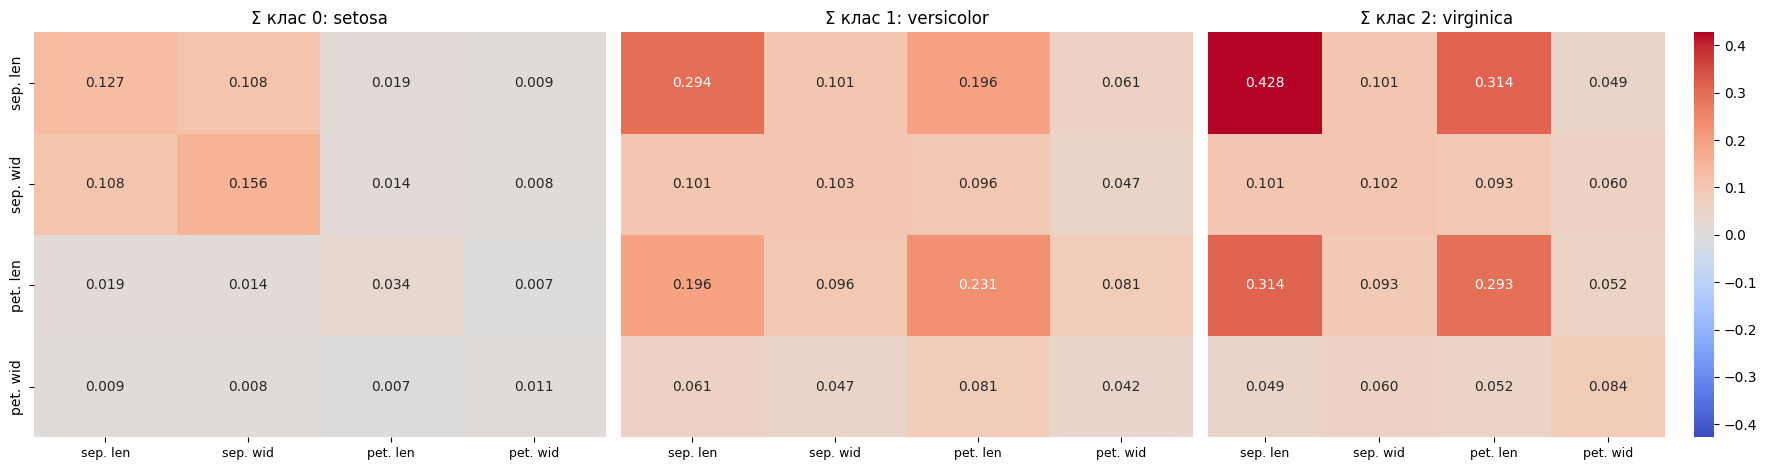

In [6]:
# Візуалізація матриць коваріації трьох класів (одна кольорова шкала для порівняння)
short = ["sep. len", "sep. wid", "pet. len", "pet. wid"]   # скорочені назви ознак
vmax = max(np.abs(c).max() for c in covs)
fig, axes = plt.subplots(1, n_classes, figsize=(18, 4.8))
for k, ax in enumerate(axes):
    sns.heatmap(covs[k], annot=True, fmt=".3f", cmap="coolwarm", center=0,
                vmin=-vmax, vmax=vmax, cbar=(k == n_classes - 1), ax=ax,
                xticklabels=short, yticklabels=short if k == 0 else False)
    ax.set_title(f"Σ клас {k}: {class_names[k]}")
    ax.tick_params(axis="x", labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()

## Крок 5. Обернені матриці коваріації

Для дискримінантної функції потрібні $\Sigma_i^{-1}$ (у квадратичній формі) та $\ln|\Sigma_i|$. Обчислюємо їх за допомогою `np.linalg.inv` і `np.linalg.slogdet`. Одразу перевіряємо коректність: добуток $\Sigma_i\,\Sigma_i^{-1}$ має дорівнювати одиничній матриці, а також дивимось на число обумовленості (чи не вироджена матриця).

In [7]:
inv_covs = [np.linalg.inv(c) for c in covs]

# slogdet повертає (знак, ln|det|) — стійкіше, ніж np.log(np.linalg.det(...))
log_dets = []
for k in range(n_classes):
    sign, logdet = np.linalg.slogdet(covs[k])
    assert sign > 0, "матриця коваріації має бути додатно визначеною"
    log_dets.append(logdet)

check = pd.DataFrame({
    "Σ·Σ⁻¹ ≈ I":       [np.allclose(covs[k] @ inv_covs[k], np.eye(X.shape[1])) for k in range(n_classes)],
    "det(Σ)":          [np.linalg.det(c) for c in covs],
    "ln|Σ|":           log_dets,
    "cond(Σ)":         [np.linalg.cond(c) for c in covs],
}, index=class_names)
display(check)

print("Обернена матриця коваріації класу 0 (setosa):")
pd.DataFrame(inv_covs[0], index=feature_names, columns=feature_names)

,Σ·Σ⁻¹ ≈ I,det(Σ),ln|Σ|,cond(Σ)
setosa,True,2.4548e-06,-12.9175,27.3824
versicolor,True,1.6950e-05,-10.9852,66.9365
virginica,True,9.2130e-05,-9.2923,24.6389


Обернена матриця коваріації класу 0 (setosa):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),20.2800,-13.3253,-5.1012,-4.4023
sepal width (cm),-13.3253,15.5158,1.3334,-0.7704
petal length (cm),-5.1012,1.3334,35.3331,-17.6083
petal width (cm),-4.4023,-0.7704,-17.6083,103.5108


## Крок 6. Апріорні імовірності класів

Апріорна імовірність оцінюється частотою класу в навчальних даних:

$$P(\omega_i)=\frac{n_i}{n}$$

In [8]:
n_train = len(y_train)
priors = [len(Xk) / n_train for Xk in X_classes]

print(pd.DataFrame({
    "n_i":  [len(Xk) for Xk in X_classes],
    "P(ω_i)": priors,
}, index=class_names))
print(f"\nСума апріорних імовірностей: {sum(priors):.4f}")

            n_i  P(ω_i)
setosa       40  0.3333
versicolor   41  0.3417
virginica    39  0.3250

Сума апріорних імовірностей: 1.0000


## Крок 7. Дискримінантна функція для одного вектора тестових даних

Реалізуємо функцію, що для вектора $x$ повертає значення $g_i(x)$ одного класу. Функція отримує вже підготовлені параметри класу (вектор середніх, матрицю коваріації, обернену матрицю, апріорну імовірність), тому їх не потрібно перераховувати для кожного тестового об'єкта.

In [9]:
def discriminant_g(x, mean, cov, inv_cov, prior):
    # Значення квадратичної дискримінантної функції g_i(x) для одного класу.
    #   g_i(x) = -1/2 (x-μ)^T Σ^{-1} (x-μ) - 1/2 ln|Σ| + ln P(ω_i)
    diff = np.asarray(x, dtype=float).reshape(-1, 1) - mean.reshape(-1, 1)   # стовпець (d × 1)
    mahalanobis_sq = (diff.T @ inv_cov @ diff).item()                         # (x-μ)^T Σ^{-1} (x-μ)
    _, log_det = np.linalg.slogdet(cov)                                       # ln|Σ|
    return -0.5 * mahalanobis_sq - 0.5 * log_det + np.log(prior)


# Перевірка на першому векторі тестової вибірки
x0 = X_test[0]
g0 = np.array([discriminant_g(x0, means[k], covs[k], inv_covs[k], priors[k])
               for k in range(n_classes)])

print(f"Вектор x0 = {x0},  справжній клас: {y_test[0]} ({class_names[y_test[0]]})")
for k in range(n_classes):
    print(f"  g_{k}(x0) = {g0[k]:10.4f}   ({class_names[k]})")
print(f"Найбільше значення у класу {g0.argmax()} ({class_names[g0.argmax()]})")

Вектор x0 = [6.1 2.8 4.7 1.2],  справжній клас: 1 (versicolor)
  g_0(x0) =  -173.8241   (setosa)
  g_1(x0) =    -0.0005   (versicolor)
  g_2(x0) =    -3.5205   (virginica)
Найбільше значення у класу 1 (versicolor)


## Крок 8. Дискримінантна функція та імовірності для всієї матриці тестових даних

Функція `discriminant_matrix` проходить по всіх рядках тестової матриці, для кожного рахує $g_i(x)$ по всіх класах і перетворює їх на апостеріорні імовірності через softmax. Щоб уникнути переповнення в `exp`, від усіх $g_i$ віднімаємо їх максимум (це не змінює результат нормування).

На відміну від прикладу вище, функція працює для **довільної кількості класів**, а не лише для трьох.

In [10]:
def discriminant_matrix(X_test, means, covs, inv_covs, priors):
    # Повертає:
    #   g_values — матриця (n_test × n_classes) значень g_i(x)
    #   g_proba  — матриця (n_test × n_classes) апостеріорних імовірностей P(ω_i | x)
    g_values, g_proba = [], []
    for x in X_test:
        g_i = np.array([
            discriminant_g(x, means[k], covs[k], inv_covs[k], priors[k])
            for k in range(len(means))
        ])
        likelihood = np.exp(g_i - g_i.max())      # стійкий softmax
        g_values.append(g_i)
        g_proba.append(likelihood / likelihood.sum())
    return np.array(g_values), np.array(g_proba)


g_val, g_proba = discriminant_matrix(X_test, means, covs, inv_covs, priors)
y_pred_own = g_val.argmax(axis=1)          # клас з найбільшим g_i

print(f"g_val: {g_val.shape}, g_proba: {g_proba.shape}")
print(f"Кожен рядок імовірностей сумується до 1: {np.allclose(g_proba.sum(axis=1), 1)}")
print(f"\nТочність власної реалізації QDA на тесті: {accuracy_score(y_test, y_pred_own):.4f}")

own_df = pd.DataFrame(
    np.hstack([g_val, g_proba]),
    columns=[f"g{k}" for k in range(n_classes)] + [f"P{k}" for k in range(n_classes)],
)
own_df["y_true"] = y_test
own_df["y_pred"] = y_pred_own
own_df.head(10)

g_val: (30, 3), g_proba: (30, 3)
Кожен рядок імовірностей сумується до 1: True

Точність власної реалізації QDA на тесті: 0.9667


,g0,g1,g2,P0,P1,P2,y_true,y_pred
0,-173.8241,-0.0005,-3.5205,3.1383e-76,9.7125e-01,2.8749e-02,1,1
1,2.5571,-61.2450,-148.7057,1.0000e+00,1.9549e-28,2.0296e-66,0,0
2,-546.9247,-28.8623,-7.4422,5.0785e-235,4.9816e-10,1.0000e+00,2,2
3,-170.2395,3.9443,-2.3206,2.2495e-76,9.9810e-01,1.8982e-03,1,1
4,-203.6067,2.4686,-5.2083,3.1801e-90,9.9954e-01,4.6318e-04,1,1
5,2.5778,-45.4492,-127.2270,1.0000e+00,1.3871e-21,4.2313e-57,0,0
6,-93.9426,1.3677,-15.3178,4.0484e-42,1.0000e+00,5.6703e-08,1,1
7,-309.4190,-23.7181,-1.7159,2.3240e-134,2.7833e-10,1.0000e+00,2,2
8,-190.9161,-3.2318,-2.8909,1.2835e-82,4.1561e-01,5.8439e-01,1,2
9,-110.4211,4.0374,-10.3744,1.9556e-50,1.0000e+00,5.5085e-07,1,1


## Крок 9. Прогноз за допомогою `QuadraticDiscriminantAnalysis()` з sklearn та порівняння

Навчаємо класифікатор `sklearn` на тих самих навчальних даних і отримуємо для тестової вибірки:

- значення дискримінантної функції (`_decision_function`),
- імовірності класів (`predict_proba`),
- прогноз класу (`predict`).

Після цього порівнюємо їх зі значеннями, отриманими власною реалізацією.

In [11]:
qda = QuadraticDiscriminantAnalysis()       # параметри за замовчуванням: без регуляризації (reg_param=0)
qda.fit(X_train, y_train)

g_sk = qda._decision_function(X_test)       # значення g_i(x) у реалізації sklearn
proba_sk = qda.predict_proba(X_test)        # імовірності P(ω_i | x)
y_pred_sk = qda.predict(X_test)             # прогноз класів

print(f"Точність sklearn QDA на тесті: {accuracy_score(y_test, y_pred_sk):.4f}")
print(f"Апріорні імовірності sklearn: {qda.priors_}")
print(f"Наші апріорні імовірності:    {np.array(priors)}")

Точність sklearn QDA на тесті: 0.9667
Апріорні імовірності sklearn: [0.3333 0.3417 0.325 ]
Наші апріорні імовірності:    [0.3333 0.3417 0.325 ]


In [12]:
# Таблиця порівняння значень g_i та імовірностей для перших 10 тестових об'єктів
compare_df = pd.DataFrame({
    **{f"g{k}_own": g_val[:, k] for k in range(n_classes)},
    **{f"g{k}_sk":  g_sk[:, k]  for k in range(n_classes)},
    **{f"P{k}_own": g_proba[:, k]  for k in range(n_classes)},
    **{f"P{k}_sk":  proba_sk[:, k] for k in range(n_classes)},
    "y_true": y_test, "pred_own": y_pred_own, "pred_sk": y_pred_sk,
})
compare_df.head(10)

,g0_own,g1_own,g2_own,g0_sk,g1_sk,g2_sk,P0_own,P1_own,P2_own,P0_sk,P1_sk,P2_sk,y_true,pred_own,pred_sk
0,-173.8241,-0.0005,-3.5205,-173.8241,-0.0005,-3.5205,3.1383e-76,9.7125e-01,2.8749e-02,3.1383e-76,9.7125e-01,2.8749e-02,1,1,1
1,2.5571,-61.2450,-148.7057,2.5571,-61.2450,-148.7057,1.0000e+00,1.9549e-28,2.0296e-66,1.0000e+00,1.9549e-28,2.0296e-66,0,0,0
2,-546.9247,-28.8623,-7.4422,-546.9247,-28.8623,-7.4422,5.0785e-235,4.9816e-10,1.0000e+00,5.0785e-235,4.9816e-10,1.0000e+00,2,2,2
3,-170.2395,3.9443,-2.3206,-170.2395,3.9443,-2.3206,2.2495e-76,9.9810e-01,1.8982e-03,2.2495e-76,9.9810e-01,1.8982e-03,1,1,1
4,-203.6067,2.4686,-5.2083,-203.6067,2.4686,-5.2083,3.1801e-90,9.9954e-01,4.6318e-04,3.1801e-90,9.9954e-01,4.6318e-04,1,1,1
5,2.5778,-45.4492,-127.2270,2.5778,-45.4492,-127.2270,1.0000e+00,1.3871e-21,4.2313e-57,1.0000e+00,1.3871e-21,4.2313e-57,0,0,0
6,-93.9426,1.3677,-15.3178,-93.9426,1.3677,-15.3178,4.0484e-42,1.0000e+00,5.6703e-08,4.0484e-42,1.0000e+00,5.6703e-08,1,1,1
7,-309.4190,-23.7181,-1.7159,-309.4190,-23.7181,-1.7159,2.3240e-134,2.7833e-10,1.0000e+00,2.3240e-134,2.7833e-10,1.0000e+00,2,2,2
8,-190.9161,-3.2318,-2.8909,-190.9161,-3.2318,-2.8909,1.2835e-82,4.1561e-01,5.8439e-01,1.2835e-82,4.1561e-01,5.8439e-01,1,2,2
9,-110.4211,4.0374,-10.3744,-110.4211,4.0374,-10.3744,1.9556e-50,1.0000e+00,5.5085e-07,1.9556e-50,1.0000e+00,5.5085e-07,1,1,1


In [13]:
# Кількісне порівняння результатів
max_diff_g     = np.abs(g_val - g_sk).max()
max_diff_proba = np.abs(g_proba - proba_sk).max()
same_pred      = np.mean(y_pred_own == y_pred_sk)

summary = pd.DataFrame({
    "Показник": [
        "Макс. абсолютна різниця значень g_i(x)",
        "Макс. абсолютна різниця імовірностей P(ω_i | x)",
        "np.allclose для g_i(x)",
        "np.allclose для імовірностей",
        "Частка однакових прогнозів класу",
        "Точність власної реалізації",
        "Точність sklearn",
    ],
    "Значення": [
        f"{max_diff_g:.3e}",
        f"{max_diff_proba:.3e}",
        str(np.allclose(g_val, g_sk)),
        str(np.allclose(g_proba, proba_sk)),
        f"{same_pred:.4f}",
        f"{accuracy_score(y_test, y_pred_own):.4f}",
        f"{accuracy_score(y_test, y_pred_sk):.4f}",
    ],
}).set_index("Показник")
summary

,Значення
Показник,
Макс. абсолютна різниця значень g_i(x),3.979e-13
Макс. абсолютна різниця імовірностей P(ω_i | x),2.165e-15
np.allclose для g_i(x),True
np.allclose для імовірностей,True
Частка однакових прогнозів класу,1.0000
Точність власної реалізації,0.9667
Точність sklearn,0.9667


In [14]:
# Які тестові об'єкти класифіковані помилково (власною реалізацією та sklearn)
wrong = np.where((y_pred_own != y_test) | (y_pred_sk != y_test))[0]

errors_df = pd.DataFrame({
    "індекс у X_test": wrong,
    "справжній клас": [class_names[i] for i in y_test[wrong]],
    "прогноз (власний)": [class_names[i] for i in y_pred_own[wrong]],
    "прогноз (sklearn)": [class_names[i] for i in y_pred_sk[wrong]],
    "P(справжнього класу), власна": [g_proba[i, y_test[i]] for i in wrong],
    "P(справжнього класу), sklearn": [proba_sk[i, y_test[i]] for i in wrong],
    "P(прогнозованого класу), власна": [g_proba[i, y_pred_own[i]] for i in wrong],
    "P(прогнозованого класу), sklearn": [proba_sk[i, y_pred_sk[i]] for i in wrong],
})
print(f"Помилково класифіковано об'єктів: {len(wrong)} із {len(y_test)}")
errors_df

Помилково класифіковано об'єктів: 1 із 30


,індекс у X_test,справжній клас,прогноз (власний),прогноз (sklearn),"P(справжнього класу), власна","P(справжнього класу), sklearn","P(прогнозованого класу), власна","P(прогнозованого класу), sklearn"
0,8,versicolor,virginica,virginica,0.4156,0.4156,0.5844,0.5844


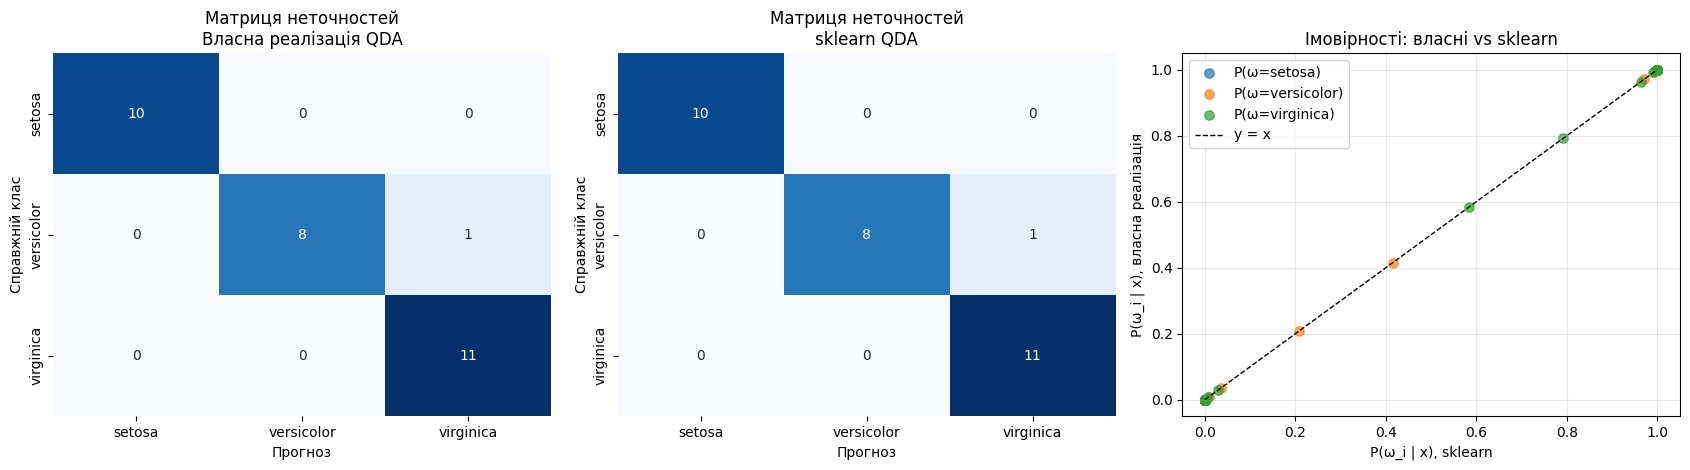

In [15]:
# Візуалізація: матриці неточностей обох методів + діаграма розсіювання «власні vs sklearn» імовірності
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

for ax, pred, title in [(axes[0], y_pred_own, "Власна реалізація QDA"),
                        (axes[1], y_pred_sk,  "sklearn QDA")]:
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, cbar=False, ax=ax)
    ax.set_title(f"Матриця неточностей\n{title}")
    ax.set_xlabel("Прогноз")
    ax.set_ylabel("Справжній клас")

for k in range(n_classes):
    axes[2].scatter(proba_sk[:, k], g_proba[:, k], s=45, alpha=0.7, label=f"P(ω={class_names[k]})")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="y = x")
axes[2].set_title("Імовірності: власні vs sklearn")
axes[2].set_xlabel("P(ω_i | x), sklearn")
axes[2].set_ylabel("P(ω_i | x), власна реалізація")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Крок 10. Висновок про ступінь схожості результатів

Ми реалізували QDA «з нуля» на `numpy` і порівняли його зі стандартним `QuadraticDiscriminantAnalysis()` з `sklearn` на однакових навчальних і тестових даних Iris (120 / 30 об'єктів, `random_state=42`).

**Що зроблено.** Для кожного з трьох класів ми відібрали навчальні об'єкти (крок 3), обчислили матриці коваріації (крок 4; збіг із `np.cov` підтверджено) та обернені до них (крок 5; перевірено $\Sigma\Sigma^{-1}=I$, матриці невироджені, числа обумовленості від ≈25 до ≈67), знайшли апріорні імовірності (крок 6: 0.3333 / 0.3417 / 0.3250). На цій основі реалізовано дискримінантну функцію для одного вектора (крок 7) і для всієї тестової матриці разом з імовірностями класів (крок 8).

**Порівняння з `sklearn` (крок 9):**

| Показник | Власна реалізація | sklearn |
|---|---|---|
| Апріорні імовірності | [0.3333, 0.3417, 0.3250] | [0.3333, 0.3417, 0.3250] |
| Макс. різниця значень $g_i(x)$ | ≈ 4·10⁻¹³ | |
| Макс. різниця імовірностей $P(\omega_i \mid x)$ | ≈ 2·10⁻¹⁵ | |
| Частка однакових прогнозів | 100 % (30 із 30) | |
| Точність на тесті | 0.9667 (29 із 30) | 0.9667 (29 із 30) |

**Висновки:**

1. **Результати практично ідентичні.** Значення дискримінантної функції та апостеріорні імовірності, отримані власною реалізацією, збігаються з `sklearn` з точністю до похибок обчислень з плаваючою комою (порядок $10^{-13}$–$10^{-15}$); `np.allclose` повертає `True`. Прогнози класів збігаються для всіх 30 тестових об'єктів, матриці неточностей однакові, а точки на графіку «власні vs sklearn» лежать на прямій $y=x$.
2. **Причина мізерної різниці.** Алгоритм по суті однаковий (оцінка $\mu_i$, $\Sigma_i$ з поправкою $n_i-1$, апріорні частоти класів, формула $g_i$, softmax), але чисельно він виконаний по-різному: у нас — через `np.linalg.inv` і `slogdet`, у `sklearn` — через SVD-розклад матриць коваріації. Тому й виникає розбіжність порядку машинної точності, яка не впливає на класифікацію.
3. **Якість моделі.** Обидві реалізації правильно класифікували 29 із 30 тестових квітів (точність ≈ 96.7 %). Клас *setosa* відокремлюється від решти безпомилково; єдина помилка — об'єкт *versicolor*, який віднесено до *virginica* (імовірності ≈ 0.42 та ≈ 0.58 — модель «сумнівалася»). Ці два види частково перекриваються в просторі ознак, тому саме між ними можливі помилки. Обидві реалізації помиляються на одному й тому самому об'єкті з однаковими імовірностями.
4. **Практичні зауваження.** Реалізація на `numpy` наочно показує механізм QDA (кожен клас має власну матрицю коваріації, звідси квадратична межа рішень), однак для практичного використання краще застосовувати `sklearn`: вона чисельно стійкіша (SVD) і має параметр регуляризації `reg_param` для випадків, коли матриця коваріації майже вироджена (мало об'єктів у класі або скорельовані ознаки). Наша функція `discriminant_matrix` на відміну від прикладу вище працює для довільної кількості класів.

**Підсумок:** власна реалізація QDA коректна та еквівалентна `QuadraticDiscriminantAnalysis()` з `sklearn` — за значеннями дискримінантних функцій, імовірностями та прогнозами класів.